# Bitcoin Price Forecasting with Heterogeneous Financial Indicators

## Problem Statement

**Research goal:** Predicting Bitcoin price using heterogeneous financial, macroeconomic, crypto-market and technical indicators, and comparing classical time-series, linear, tree-based, ensemble and neural forecasting methods.

The project is a supervised forecasting/data mining task. For each observation frequency, the feature vector available at time `t` is used to predict the Bitcoin price at `t+1`. This one-step-ahead framing avoids using same-period target information as if it were known before the forecast.

The target variable is `BTC`. The explanatory variables include crypto-market assets, equity/ETF proxies, commodities, FX rates, technical indicators, calendar variables, macroeconomic indicators, blockchain/market-sentiment variables, and lagged or rolling BTC features.


## Setup

The notebook uses frozen CSV datasets created by the existing data collection scripts. No external API call is required to reproduce the report.


In [1]:
import os
from pathlib import Path
import warnings
from collections import OrderedDict

os.environ.setdefault('MPLCONFIGDIR', '/private/tmp/matplotlib')
os.environ.setdefault('XDG_CACHE_HOME', '/private/tmp')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

import statsmodels.api as sm

try:
    from lightgbm import LGBMRegressor
    HAS_LIGHTGBM = True
except Exception:
    HAS_LIGHTGBM = False

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)


## Data Collection

The project uses three consolidated datasets from the existing BTC forecasting project:

- `new_day_df.csv`: daily observations.
- `new_hour_df.csv`: hourly observations.
- `new_week_df.csv`: weekly observations.

The raw collection and merging logic is kept in `get_data.py`. The report uses the frozen CSV files so that all experiments are reproducible without network access. The minimum course requirement is at least 50 objects and 7-10 features; every dataset used here is above that threshold.


In [2]:
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'new_day_df.csv').exists():
    PROJECT_DIR = Path('/Users/tigran/python_projects_epta/учеба/диплом/ACTUAL_VERSION')

DATA_CONFIG = OrderedDict({
    'daily': {
        'file': 'new_day_df.csv',
        'date_col': 'Date',
        'test_size': 216,
        'horizon': 1,
        'ma_window': 7,
        'seasonal_period': 7,
        'max_features': 30,
        'error_window': 14,
    },
    'hourly': {
        'file': 'new_hour_df.csv',
        'date_col': 'Datetime',
        'test_size': 0.20,
        'horizon': 1,
        'ma_window': 24,
        'seasonal_period': 24,
        'max_features': 25,
        'error_window': 168,
    },
    'weekly': {
        'file': 'new_week_df.csv',
        'date_col': 'Date',
        'test_size': 52,
        'horizon': 1,
        'ma_window': 4,
        'seasonal_period': 52,
        'max_features': 20,
        'error_window': 4,
    },
})

def load_dataset(file_name, date_col):
    df = pd.read_csv(PROJECT_DIR / file_name, parse_dates=[date_col])
    df = df.sort_values(date_col).set_index(date_col)
    df = df.replace([np.inf, -np.inf], np.nan)
    return df

datasets = {
    frequency: load_dataset(cfg['file'], cfg['date_col'])
    for frequency, cfg in DATA_CONFIG.items()
}

for frequency, df in datasets.items():
    print(f'{frequency}: {df.shape[0]} rows, {df.shape[1]} columns, {df.index.min()} -> {df.index.max()}')


daily: 2630 rows, 97 columns, 2018-02-23 00:00:00 -> 2025-05-06 00:00:00
hourly: 17354 rows, 83 columns, 2023-05-12 20:00:00 -> 2025-05-04 21:00:00
weekly: 369 rows, 86 columns, 2018-04-09 00:00:00 -> 2025-04-28 00:00:00


## Dataset Summary with Basic Statistics and Plots

This section checks dataset size, observation periods, feature groups, missing values, basic target statistics, and target distribution.


In [3]:
CRYPTO_COLS = {
    'BTC', 'ETH', 'Bitcoin_Cash', 'Cardano', 'Dogecoin', 'Ethereum_Classic',
    'Chainlink', 'Litecoin', 'TRON', 'Tether', 'Stellar', 'XRP', 'BTC_Supply',
    'Feer_Greed_value'
}
MACRO_COLS = {
    'Unemployment_Rate', 'Non_Farm_Payrolls', 'Initial_Jobless_Claims', 'CPI',
    'PCE_Price_Index', 'Consumer_Confidence_Index', 'Retail_Sales', 'Housing_Starts',
    'Building_Permits', 'M2_Money_Supply', 'Real_Interest_Rate', 'Fed_Funds_Rate',
    'Reverse_Repo_Volume', 'Debt', 'Real_GDP'
}
TECHNICAL_TOKENS = (
    'RSI', 'MACD', 'ATR', 'OBV', 'SMA', 'EMA', 'TEMA', 'KAMA', 'HMA', 'ALMA',
    'T3', 'SSF', 'VIDYA', 'ZL_EMA', 'BTC_lag', 'BTC_mean', 'BTC_std',
    'Open', 'High', 'Low', 'Close', 'Volume', 'Taker buy'
)
CALENDAR_COLS = {'day', 'month', 'quarter', 'year', 'day_of_week', 'hour', 'minute', 'is_holiday'}
FX_TOKENS = ('USD/', 'EUR/', 'GBP/', 'AUD/')
COMMODITY_COLS = {'Gold', 'Silver', 'Copper', 'Platinum', 'Brent_Oil', 'WTI', 'Brent', 'Natural_Gas'}

def feature_group(col):
    if col in CALENDAR_COLS:
        return 'calendar'
    if col in MACRO_COLS:
        return 'macroeconomic'
    if col in CRYPTO_COLS:
        return 'crypto-market'
    if col in COMMODITY_COLS:
        return 'commodities'
    if any(token in col for token in TECHNICAL_TOKENS):
        return 'technical/lagged BTC'
    if any(token in col for token in FX_TOKENS):
        return 'FX'
    return 'equity/ETF/market index'

summary_rows = []
group_rows = []
for frequency, df in datasets.items():
    target = df['BTC']
    missing_by_col = df.isna().sum()
    summary_rows.append({
        'frequency': frequency,
        'objects': len(df),
        'features_excluding_target': df.shape[1] - 1,
        'start': df.index.min(),
        'end': df.index.max(),
        'missing_values_total': int(missing_by_col.sum()),
        'columns_with_missing': int((missing_by_col > 0).sum()),
        'BTC_mean': target.mean(),
        'BTC_std': target.std(),
        'BTC_min': target.min(),
        'BTC_median': target.median(),
        'BTC_max': target.max(),
    })
    feature_groups = pd.Series([feature_group(col) for col in df.columns if col != 'BTC']).value_counts()
    for group, count in feature_groups.items():
        group_rows.append({'frequency': frequency, 'feature_group': group, 'count': int(count)})

summary_df = pd.DataFrame(summary_rows)
feature_group_df = pd.DataFrame(group_rows).sort_values(['frequency', 'feature_group'])

display(summary_df)
display(feature_group_df.pivot_table(index='feature_group', columns='frequency', values='count', fill_value=0).astype(int))


,frequency,objects,features_excluding_target,start,end,missing_values_total,columns_with_missing,BTC_mean,BTC_std,BTC_min,BTC_median,BTC_max
0,daily,2630,96,2018-02-23 00:00:00,2025-05-06 00:00:00,0,0,31451.540539,25606.924708,3235.051208,25291.607178,106460.345703
1,hourly,17354,82,2023-05-12 20:00:00,2025-05-04 21:00:00,0,0,59131.765470,24235.438587,24867.893555,61414.339844,108126.986328
2,weekly,369,85,2018-04-09 00:00:00,2025-04-28 00:00:00,0,0,31778.749081,25554.473940,3336.078552,26161.846191,103487.810547


frequency,daily,hourly,weekly
feature_group,,,
FX,6,6,6
calendar,4,3,3
commodities,8,7,8
crypto-market,13,11,13
equity/ETF/market index,30,30,30
macroeconomic,15,0,15
technical/lagged BTC,20,25,10


In [4]:
basic_stats = pd.concat(
    {frequency: df['BTC'].describe() for frequency, df in datasets.items()},
    axis=1
).T
basic_stats['skew'] = [datasets[f]['BTC'].skew() for f in basic_stats.index]
basic_stats['kurtosis'] = [datasets[f]['BTC'].kurtosis() for f in basic_stats.index]
display(basic_stats.round(2))


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
daily,2630.0,31451.54,25606.92,3235.05,9184.86,25291.61,47015.63,106460.35,0.96,0.10
hourly,17354.0,59131.77,24235.44,24867.89,35780.47,61414.34,72904.39,108126.99,0.20,-1.12
weekly,369.0,31778.75,25554.47,3336.08,9235.76,26161.85,47304.37,103487.81,0.94,0.06


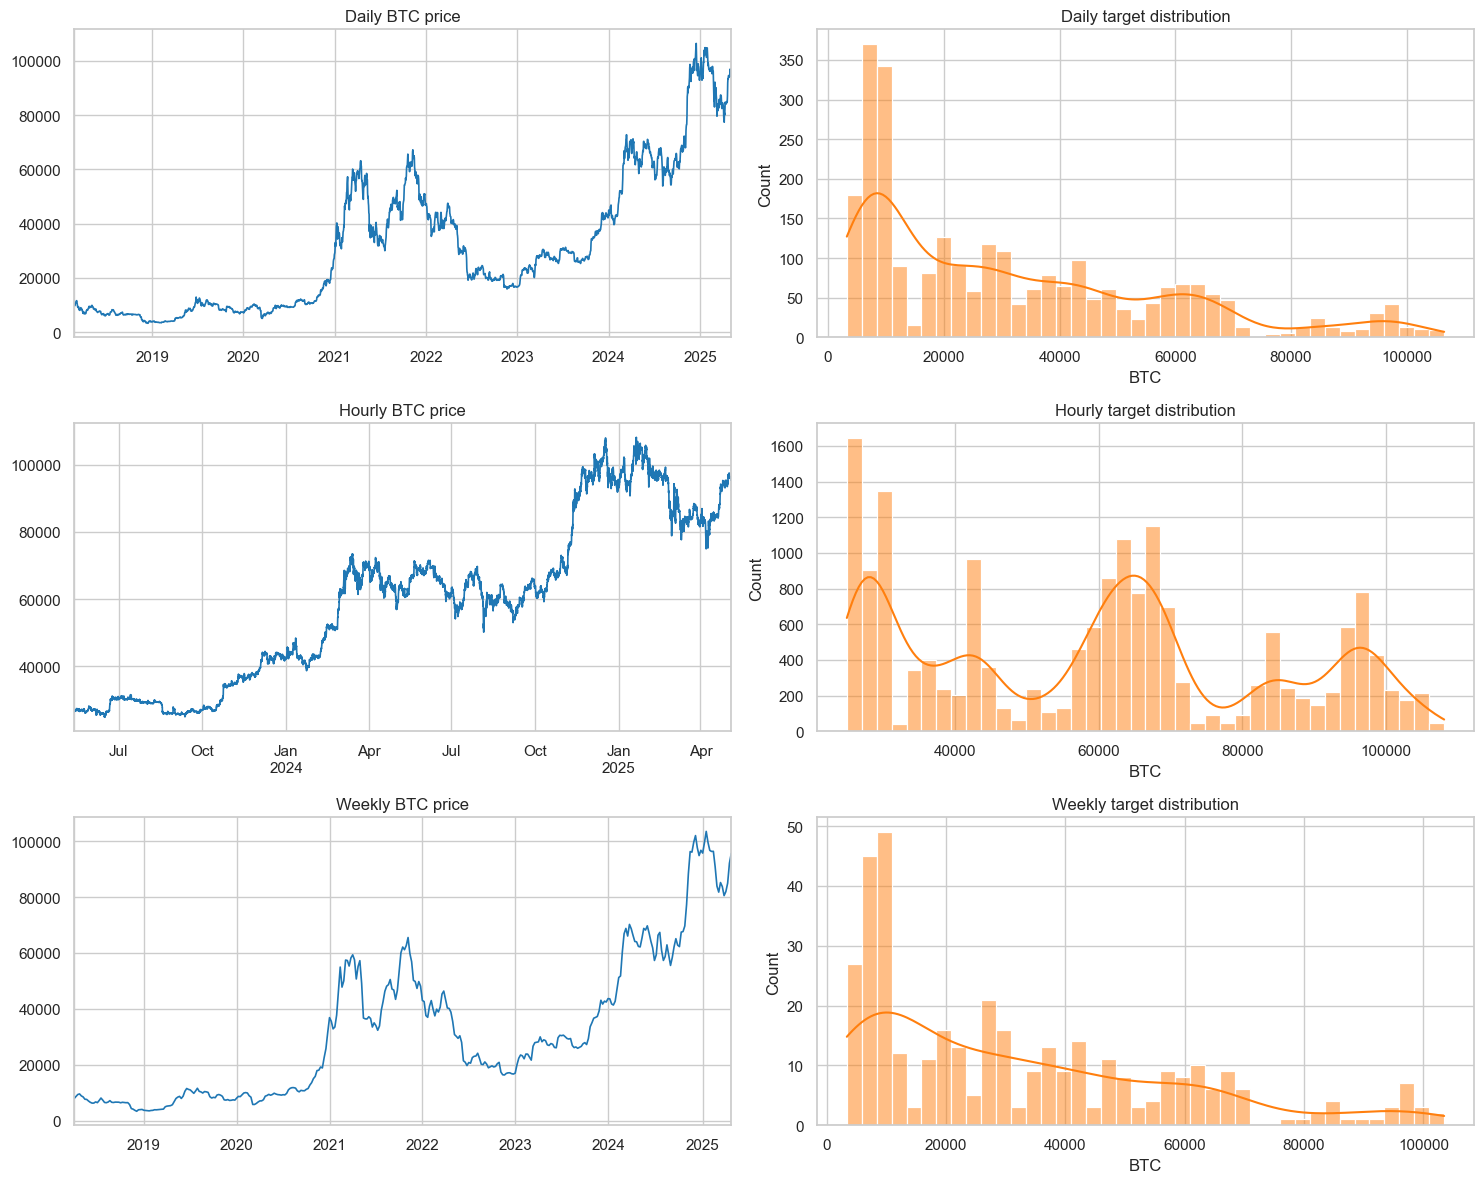

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
for row, (frequency, df) in enumerate(datasets.items()):
    df['BTC'].plot(ax=axes[row, 0], color='tab:blue', linewidth=1.2)
    axes[row, 0].set_title(f'{frequency.title()} BTC price')
    axes[row, 0].set_xlabel('')
    sns.histplot(df['BTC'], bins=40, kde=True, ax=axes[row, 1], color='tab:orange')
    axes[row, 1].set_title(f'{frequency.title()} target distribution')
plt.tight_layout()
plt.show()


### Missing Values and Outliers

The consolidated files have no missing values. The modeling pipeline still includes median imputation to make the workflow robust to future data refreshes. Outliers are handled inside the training pipeline by clipping numeric features to train-fitted 1st and 99th percentiles before robust scaling.


In [6]:
def iqr_outlier_count(frame):
    numeric = frame.select_dtypes(include=[np.number])
    q1 = numeric.quantile(0.25)
    q3 = numeric.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = numeric.lt(lower, axis=1) | numeric.gt(upper, axis=1)
    return mask.sum().sort_values(ascending=False)

missing_table = pd.DataFrame({
    frequency: df.isna().sum() for frequency, df in datasets.items()
}).fillna(0).astype(int)

display(missing_table.sum().rename('missing_values_by_frequency').to_frame())

outlier_rows = []
for frequency, df in datasets.items():
    counts = iqr_outlier_count(df).head(10)
    for feature, count in counts.items():
        outlier_rows.append({'frequency': frequency, 'feature': feature, 'IQR_outlier_count': int(count)})

display(pd.DataFrame(outlier_rows))


,missing_values_by_frequency
daily,0
hourly,0
weekly,0


,frequency,feature,IQR_outlier_count
0,daily,Initial_Jobless_Claims,567
1,daily,Tether,524
2,daily,Unemployment_Rate,487
3,daily,ARKK_ETF,418
4,daily,MicroStrategy,348
5,daily,NVIDIA,344
6,daily,MACD,309
7,daily,Riot_Blockchain,305
8,daily,Taker buy base volume,283
9,daily,Volume,281


## Methodology

The complete pipeline is:

1. Load frozen datasets and validate size, period, missing values, and feature groups.
2. Convert the task to one-step-ahead forecasting: features at `t` predict `BTC` at `t+1`.
3. Use time-based train/test splits only. No shuffling is used.
4. Select features using only the training segment. The default selection keeps the strongest train-period absolute correlations with the next-period target.
5. Fit preprocessing only on training data: median imputation, 1/99 percentile clipping, robust scaling.
6. Train baselines and machine learning models.
7. Compare models by MAE, RMSE, SMAPE, MASE, and train/test gap.
8. Interpret models through feature importance and optional SHAP where available.
9. Analyze residuals, worst forecast intervals, and sharp BTC growth/drop periods.

The compared methods cover more than two ML/DM approaches: naive and seasonal baselines, SARIMAX, regularized linear regression, random forest, gradient boosting, LightGBM/XGBoost when available, validation stacking, KNN, and an MLP neural regressor.


In [7]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    ratio = np.divide(np.abs(y_true - y_pred), denominator, out=np.zeros_like(denominator), where=denominator != 0)
    return float(np.mean(ratio))


def mase(y_true, y_pred, y_train):
    y_train = np.asarray(y_train, dtype=float)
    scale = np.mean(np.abs(np.diff(y_train)))
    if scale == 0 or np.isnan(scale):
        return np.nan
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))) / scale)


def regression_metrics(y_true, y_pred, y_train):
    frame = pd.concat([
        pd.Series(y_true, name='true'),
        pd.Series(y_pred, name='pred')
    ], axis=1).dropna()
    if frame.empty:
        return {'MAE': np.nan, 'RMSE': np.nan, 'SMAPE': np.nan, 'MASE': np.nan}
    return {
        'MAE': mean_absolute_error(frame['true'], frame['pred']),
        'RMSE': np.sqrt(mean_squared_error(frame['true'], frame['pred'])),
        'SMAPE': 100 * smape(frame['true'], frame['pred']),
        'MASE': mase(frame['true'], frame['pred'], y_train),
    }


class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_bounds_ = np.nanquantile(X, self.lower, axis=0)
        self.upper_bounds_ = np.nanquantile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)


def make_preprocessed_model(model, scale=True):
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('clipper', QuantileClipper(lower=0.01, upper=0.99)),
    ]
    if scale:
        steps.append(('scaler', RobustScaler()))
    steps.append(('model', model))
    return Pipeline(steps)


SMAPE_SCORER = make_scorer(smape, greater_is_better=False)


In [8]:
def make_supervised_frame(df, target_col='BTC', horizon=1):
    if horizon < 1:
        raise ValueError('horizon must be at least 1')
    target_index = df.index[horizon:]
    X = df.drop(columns=[target_col]).iloc[:-horizon].copy()
    X.index = target_index
    y = pd.Series(df[target_col].iloc[horizon:].to_numpy(), index=target_index, name=target_col)
    return X, y


def make_baselines(df, y_index, target_col='BTC', horizon=1, ma_window=7, seasonal_period=7):
    target = df[target_col]
    baselines = pd.DataFrame(index=y_index)
    baselines['Naive last value'] = target.shift(horizon).loc[y_index]
    baselines['Moving average'] = target.shift(horizon).rolling(ma_window, min_periods=1).mean().loc[y_index]
    baselines['Seasonal naive'] = target.shift(seasonal_period).loc[y_index]
    return baselines


def resolve_test_size(configured_test_size, n_rows):
    if isinstance(configured_test_size, float):
        return int(round(n_rows * configured_test_size))
    return int(configured_test_size)


def time_split(X, y, test_size):
    if test_size <= 0 or test_size >= len(y):
        raise ValueError(f'invalid test_size={test_size} for n={len(y)}')
    return X.iloc[:-test_size], X.iloc[-test_size:], y.iloc[:-test_size], y.iloc[-test_size:]


def select_top_features(X_train, y_train, max_features):
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    scores = {}
    for col in numeric_cols:
        series = X_train[col]
        if series.nunique(dropna=True) <= 1:
            continue
        corr = series.corr(y_train)
        if pd.notna(corr):
            scores[col] = abs(corr)
    score_series = pd.Series(scores).sort_values(ascending=False)
    selected = score_series.head(max_features).index.tolist()
    if not selected:
        selected = numeric_cols[:max_features]
    return selected, score_series


prepared = OrderedDict()
feature_selection_rows = []
for frequency, cfg in DATA_CONFIG.items():
    X, y = make_supervised_frame(datasets[frequency], horizon=cfg['horizon'])
    baselines = make_baselines(
        datasets[frequency],
        y.index,
        horizon=cfg['horizon'],
        ma_window=cfg['ma_window'],
        seasonal_period=cfg['seasonal_period'],
    )
    test_size = resolve_test_size(cfg['test_size'], len(y))
    X_train, X_test, y_train, y_test = time_split(X, y, test_size)
    selected_features, feature_scores = select_top_features(X_train, y_train, cfg['max_features'])
    prepared[frequency] = {
        'X': X,
        'y': y,
        'baselines': baselines,
        'test_size': test_size,
        'X_train': X_train[selected_features],
        'X_test': X_test[selected_features],
        'y_train': y_train,
        'y_test': y_test,
        'selected_features': selected_features,
        'feature_scores': feature_scores,
    }
    for rank, (feature, score) in enumerate(feature_scores.head(10).items(), start=1):
        feature_selection_rows.append({
            'frequency': frequency,
            'rank': rank,
            'feature': feature,
            'abs_train_corr_with_next_BTC': score,
        })

split_summary = pd.DataFrame([
    {
        'frequency': frequency,
        'train_rows': len(data['y_train']),
        'test_rows': len(data['y_test']),
        'selected_features': len(data['selected_features']),
        'test_start': data['y_test'].index.min(),
        'test_end': data['y_test'].index.max(),
    }
    for frequency, data in prepared.items()
])

display(split_summary)
display(pd.DataFrame(feature_selection_rows))


,frequency,train_rows,test_rows,selected_features,test_start,test_end
0,daily,2413,216,30,2024-10-03 00:00:00,2025-05-06 00:00:00
1,hourly,13882,3471,25,2024-12-11 07:00:00,2025-05-04 21:00:00
2,weekly,316,52,20,2024-05-06 00:00:00,2025-04-28 00:00:00


,frequency,rank,feature,abs_train_corr_with_next_BTC
0,daily,1,Close,0.999072
1,daily,2,High,0.998467
2,daily,3,Low,0.998291
3,daily,4,Open,0.997665
4,daily,5,BTC_lag1,0.996149
5,daily,6,HMA_20,0.996133
6,daily,7,BTC_mean5,0.995613
7,daily,8,BTC_lag2,0.994705
8,daily,9,EMA_20,0.992234
9,daily,10,BTC_lag5,0.990035


## Experiment Setup and Results

All models are evaluated on the same time-based splits. Hyperparameter selection for linear models uses `TimeSeriesSplit` on the training segment. Baselines do not use future observations. All scalers, imputers, clipping bounds, and model parameters are fit only on training data.


In [9]:
def build_model_specs():
    specs = OrderedDict()

    ridge = make_preprocessed_model(Ridge())
    specs['Ridge'] = GridSearchCV(
        ridge,
        param_grid={'model__alpha': np.logspace(-3, 3, 9)},
        scoring=SMAPE_SCORER,
        cv=TimeSeriesSplit(n_splits=3),
        n_jobs=-1,
    )

    lasso = make_preprocessed_model(Lasso(max_iter=8000, random_state=RANDOM_STATE))
    specs['Lasso'] = GridSearchCV(
        lasso,
        param_grid={'model__alpha': np.logspace(-4, 1, 8)},
        scoring=SMAPE_SCORER,
        cv=TimeSeriesSplit(n_splits=3),
        n_jobs=-1,
    )

    elastic = make_preprocessed_model(ElasticNet(max_iter=8000, random_state=RANDOM_STATE))
    specs['ElasticNet'] = GridSearchCV(
        elastic,
        param_grid={
            'model__alpha': np.logspace(-4, 1, 7),
            'model__l1_ratio': [0.15, 0.5, 0.85],
        },
        scoring=SMAPE_SCORER,
        cv=TimeSeriesSplit(n_splits=3),
        n_jobs=-1,
    )

    specs['KNN'] = make_preprocessed_model(KNeighborsRegressor(n_neighbors=7, weights='distance'))

    specs['RandomForest'] = make_preprocessed_model(
        RandomForestRegressor(
            n_estimators=220,
            min_samples_leaf=2,
            max_features='sqrt',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        scale=False,
    )

    specs['HistGradientBoosting'] = make_preprocessed_model(
        HistGradientBoostingRegressor(
            max_iter=260,
            learning_rate=0.05,
            l2_regularization=0.05,
            random_state=RANDOM_STATE,
        ),
        scale=False,
    )

    if HAS_LIGHTGBM:
        specs['LightGBM'] = make_preprocessed_model(
            LGBMRegressor(
                n_estimators=320,
                learning_rate=0.03,
                num_leaves=31,
                min_child_samples=20,
                subsample=0.85,
                colsample_bytree=0.85,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1,
            ),
            scale=False,
        )

    if HAS_XGBOOST:
        specs['XGBoost'] = make_preprocessed_model(
            XGBRegressor(
                objective='reg:squarederror',
                n_estimators=320,
                learning_rate=0.03,
                max_depth=3,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_lambda=1.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
            scale=False,
        )

    specs['MLP neural regressor'] = make_preprocessed_model(
        MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation='relu',
            alpha=1e-3,
            learning_rate_init=1e-3,
            early_stopping=True,
            validation_fraction=0.15,
            max_iter=220,
            random_state=RANDOM_STATE,
        )
    )

    return specs


def fit_sarimax(y_train, y_test, order=(1, 1, 1)):
    scaler = RobustScaler().fit(y_train.to_numpy().reshape(-1, 1))
    y_train_scaled = scaler.transform(y_train.to_numpy().reshape(-1, 1)).ravel()
    model = sm.tsa.SARIMAX(
        y_train_scaled,
        order=order,
        seasonal_order=(0, 0, 0, 0),
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=100)

    train_pred_scaled = np.asarray(model.fittedvalues)
    test_pred_scaled = np.asarray(model.get_forecast(steps=len(y_test)).predicted_mean)
    train_pred = pd.Series(
        scaler.inverse_transform(train_pred_scaled.reshape(-1, 1)).ravel(),
        index=y_train.index,
        name='SARIMAX',
    )
    test_pred = pd.Series(
        scaler.inverse_transform(test_pred_scaled.reshape(-1, 1)).ravel(),
        index=y_test.index,
        name='SARIMAX',
    )
    return train_pred, test_pred, model


def fit_validation_stacking(X_train, y_train, X_test):
    split = int(len(X_train) * 0.8)
    X_base, X_meta = X_train.iloc[:split], X_train.iloc[split:]
    y_base, y_meta = y_train.iloc[:split], y_train.iloc[split:]

    base_builders = OrderedDict({
        'ridge': lambda: make_preprocessed_model(Ridge(alpha=1.0)),
        'rf': lambda: make_preprocessed_model(
            RandomForestRegressor(
                n_estimators=180,
                min_samples_leaf=2,
                max_features='sqrt',
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
            scale=False,
        ),
        'knn': lambda: make_preprocessed_model(KNeighborsRegressor(n_neighbors=7, weights='distance')),
    })
    if HAS_LIGHTGBM:
        base_builders['lgbm'] = lambda: make_preprocessed_model(
            LGBMRegressor(
                n_estimators=220,
                learning_rate=0.04,
                num_leaves=31,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1,
            ),
            scale=False,
        )

    meta_train = []
    meta_test = []
    full_train_predictions = []
    fitted_base_models = OrderedDict()

    for name, builder in base_builders.items():
        base_model_for_meta = builder()
        base_model_for_meta.fit(X_base, y_base)
        meta_train.append(base_model_for_meta.predict(X_meta))

        full_model = builder()
        full_model.fit(X_train, y_train)
        fitted_base_models[name] = full_model
        meta_test.append(full_model.predict(X_test))
        full_train_predictions.append(full_model.predict(X_train))

    meta_X_train = np.column_stack(meta_train)
    meta_X_test = np.column_stack(meta_test)
    meta_X_full_train = np.column_stack(full_train_predictions)

    meta_model = Ridge(alpha=1.0)
    meta_model.fit(meta_X_train, y_meta)

    train_pred = pd.Series(meta_model.predict(meta_X_full_train), index=y_train.index, name='Validation stacking')
    test_pred = pd.Series(meta_model.predict(meta_X_test), index=X_test.index, name='Validation stacking')
    return train_pred, test_pred, {'base_models': fitted_base_models, 'meta_model': meta_model}


In [10]:
def add_result(rows, prediction_store, frequency, model_name, y_train, train_pred, y_test, test_pred, model_object, comment):
    train_metrics = regression_metrics(y_train, train_pred, y_train)
    test_metrics = regression_metrics(y_test, test_pred, y_train)
    rows.append({
        'model': model_name,
        'frequency': frequency,
        'MAE': test_metrics['MAE'],
        'RMSE': test_metrics['RMSE'],
        'SMAPE': test_metrics['SMAPE'],
        'MASE': test_metrics['MASE'],
        'train/test gap': test_metrics['SMAPE'] - train_metrics['SMAPE'],
        'train_SMAPE': train_metrics['SMAPE'],
        'comment': comment,
    })
    prediction_store.setdefault(frequency, {})[model_name] = {
        'train_pred': pd.Series(train_pred, index=y_train.index),
        'test_pred': pd.Series(test_pred, index=y_test.index),
        'model': model_object,
    }


result_rows = []
prediction_store = OrderedDict()

for frequency, data in prepared.items():
    print(f'Running experiments for {frequency}...')
    X_train = data['X_train']
    X_test = data['X_test']
    y_train = data['y_train']
    y_test = data['y_test']

    baseline_train = data['baselines'].loc[y_train.index]
    baseline_test = data['baselines'].loc[y_test.index]
    baseline_comments = {
        'Naive last value': 'Previous observed BTC; mandatory persistence benchmark.',
        'Moving average': f"Rolling mean over the last {DATA_CONFIG[frequency]['ma_window']} observations.",
        'Seasonal naive': f"Value from {DATA_CONFIG[frequency]['seasonal_period']} observations earlier.",
    }
    for baseline_name in baseline_train.columns:
        add_result(
            result_rows,
            prediction_store,
            frequency,
            baseline_name,
            y_train,
            baseline_train[baseline_name],
            y_test,
            baseline_test[baseline_name],
            None,
            baseline_comments[baseline_name],
        )

    try:
        sarimax_train_pred, sarimax_test_pred, sarimax_model = fit_sarimax(y_train, y_test)
        add_result(
            result_rows,
            prediction_store,
            frequency,
            'SARIMAX(1,1,1)',
            y_train,
            sarimax_train_pred,
            y_test,
            sarimax_test_pred,
            sarimax_model,
            'Classical univariate time-series benchmark; forecast uses only train-fitted model.',
        )
    except Exception as exc:
        print(f'SARIMAX failed for {frequency}: {exc}')

    for model_name, model in build_model_specs().items():
        try:
            fitted = clone(model)
            fitted.fit(X_train, y_train)
            train_pred = pd.Series(fitted.predict(X_train), index=y_train.index)
            test_pred = pd.Series(fitted.predict(X_test), index=y_test.index)
            add_result(
                result_rows,
                prediction_store,
                frequency,
                model_name,
                y_train,
                train_pred,
                y_test,
                test_pred,
                fitted,
                'Train-only preprocessing and model fit; selected features fixed before fitting.',
            )
        except Exception as exc:
            print(f'{model_name} failed for {frequency}: {exc}')

    try:
        stack_train_pred, stack_test_pred, stack_object = fit_validation_stacking(X_train, y_train, X_test)
        add_result(
            result_rows,
            prediction_store,
            frequency,
            'Validation stacking',
            y_train,
            stack_train_pred,
            y_test,
            stack_test_pred,
            stack_object,
            'Meta-model is trained on a late train validation block, not on test data.',
        )
    except Exception as exc:
        print(f'Validation stacking failed for {frequency}: {exc}')

results_df = pd.DataFrame(result_rows).sort_values(['frequency', 'SMAPE', 'MAE']).reset_index(drop=True)
results_display = results_df[['model', 'frequency', 'MAE', 'RMSE', 'SMAPE', 'MASE', 'train/test gap', 'comment']].copy()
for col in ['MAE', 'RMSE', 'SMAPE', 'MASE', 'train/test gap']:
    results_display[col] = results_display[col].astype(float).round(3)

display(results_display)


Running experiments for daily...


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Running experiments for hourly...


Running experiments for weekly...


,model,frequency,MAE,RMSE,SMAPE,MASE,train/test gap,comment
0,Naive last value,daily,1377.118,1837.820,1.569,2.742,-0.317,Previous observed BTC; mandatory persistence b...
1,Moving average,daily,2618.082,3473.692,3.005,5.213,-1.103,Rolling mean over the last 7 observations.
2,Seasonal naive,daily,4072.709,5402.207,4.704,8.109,-1.869,Value from 7 observations earlier.
3,MLP neural regressor,daily,13561.742,15099.249,15.946,27.001,-8.564,Train-only preprocessing and model fit; select...
4,ElasticNet,daily,19499.756,22130.632,23.767,38.824,21.227,Train-only preprocessing and model fit; select...
5,Ridge,daily,19586.046,22239.140,23.888,38.995,21.592,Train-only preprocessing and model fit; select...
6,Lasso,daily,19685.055,22347.325,24.025,39.192,22.164,Train-only preprocessing and model fit; select...
7,Validation stacking,daily,19849.089,22487.571,24.260,39.519,10.699,Meta-model is trained on a late train validati...
8,XGBoost,daily,20907.692,23572.874,25.768,41.627,24.039,Train-only preprocessing and model fit; select...
9,LightGBM,daily,21102.158,23684.464,26.057,42.014,24.699,Train-only preprocessing and model fit; select...


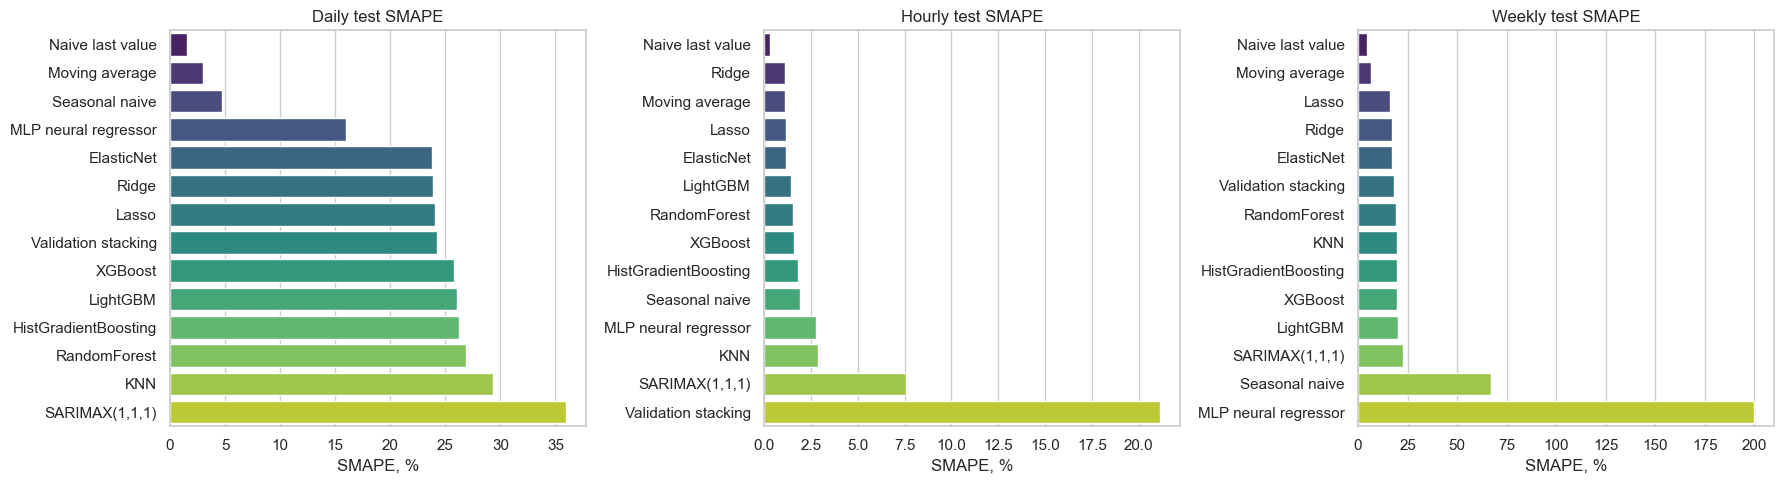

,frequency,model,MAE,RMSE,SMAPE,MASE,train/test gap
0,daily,Naive last value,1377.118,1837.820,1.569,2.742,-0.317
14,hourly,Naive last value,278.462,431.830,0.303,2.014,0.048
28,weekly,Naive last value,3261.906,3965.763,4.341,2.373,-1.240


,frequency,model,MAE,RMSE,SMAPE,MASE,train/test gap
3,daily,MLP neural regressor,13561.742,15099.249,15.946,27.001,-8.564
15,hourly,Ridge,1100.929,2104.493,1.122,7.963,0.842
30,weekly,Lasso,12810.996,17305.400,16.158,9.319,10.803


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, frequency in zip(axes, prepared.keys()):
    subset = results_df[results_df['frequency'] == frequency].sort_values('SMAPE')
    sns.barplot(data=subset, x='SMAPE', y='model', ax=ax, palette='viridis')
    ax.set_title(f'{frequency.title()} test SMAPE')
    ax.set_xlabel('SMAPE, %')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

best_by_frequency = results_df.loc[
    results_df.groupby('frequency')['SMAPE'].idxmin(),
    ['frequency', 'model', 'MAE', 'RMSE', 'SMAPE', 'MASE', 'train/test gap']
]
display(best_by_frequency.round(3))

BASELINE_MODELS = {'Naive last value', 'Moving average', 'Seasonal naive', 'SARIMAX(1,1,1)'}
ml_candidates = results_df[~results_df['model'].isin(BASELINE_MODELS)].copy()
best_interpretable = ml_candidates.loc[
    ml_candidates.groupby('frequency')['SMAPE'].idxmin(),
    ['frequency', 'model', 'MAE', 'RMSE', 'SMAPE', 'MASE', 'train/test gap']
]
display(best_interpretable.round(3))


## Interpretation

Feature interpretation is based on train-selected predictors and permutation importance on the test segment. This is model-agnostic and remains available even when SHAP is not installed. SHAP is included as an optional additional cell for tree models.


,frequency,model,feature,importance_mean,importance_std
0,daily,MLP neural regressor,ATR,1000.5631,85.8204
1,daily,MLP neural regressor,T3_20_0.7,95.2182,7.5187
2,daily,MLP neural regressor,BTC_lag10,83.3138,5.0939
3,daily,MLP neural regressor,BTC_lag2,78.0045,7.8511
4,daily,MLP neural regressor,HMA_20,76.7794,9.0781
5,daily,MLP neural regressor,BTC_lag1,75.4898,8.2678
6,daily,MLP neural regressor,High,74.2682,8.4031
7,daily,MLP neural regressor,Open,73.8663,8.7137
8,daily,MLP neural regressor,BTC_mean5,72.8962,7.6963
9,daily,MLP neural regressor,BTC_lag5,72.8260,7.3732


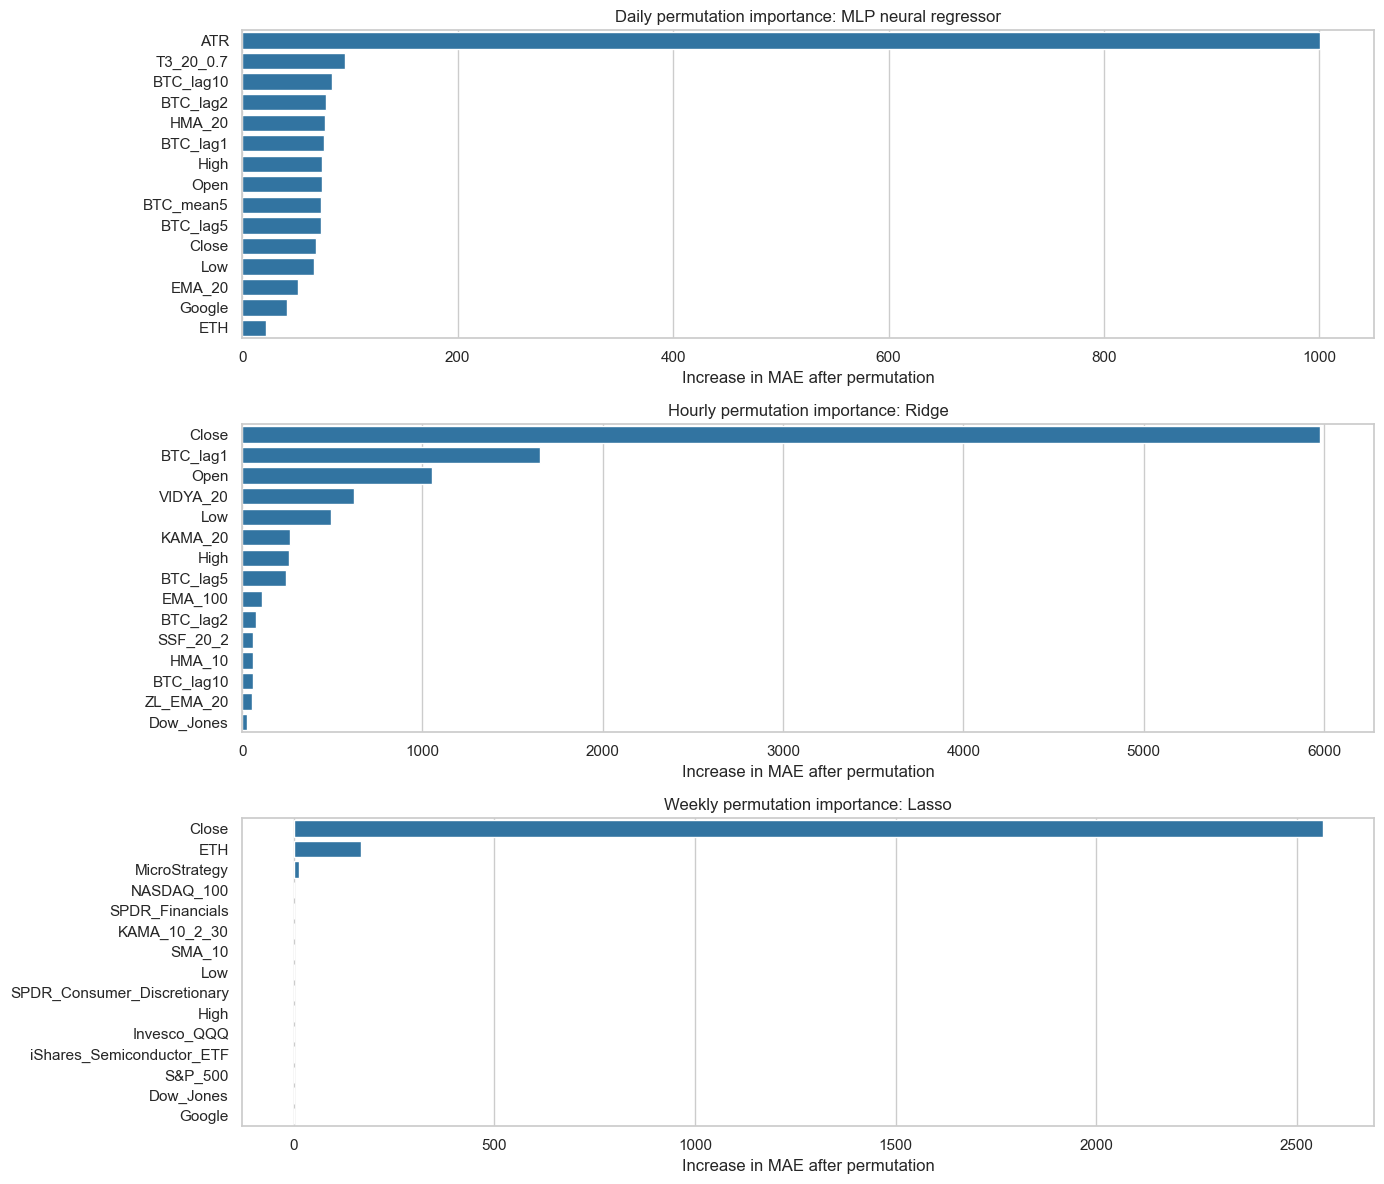

In [12]:
def permutation_importance_table(frequency, model_name, n_repeats=5, top_n=15):
    data = prepared[frequency]
    stored = prediction_store[frequency][model_name]
    model = stored['model']
    if model is None or not hasattr(model, 'predict'):
        return pd.DataFrame()
    importance = permutation_importance(
        model,
        data['X_test'],
        data['y_test'],
        n_repeats=n_repeats,
        random_state=RANDOM_STATE,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
    )
    table = pd.DataFrame({
        'frequency': frequency,
        'model': model_name,
        'feature': data['X_test'].columns,
        'importance_mean': importance.importances_mean,
        'importance_std': importance.importances_std,
    }).sort_values('importance_mean', ascending=False).head(top_n)
    return table

importance_tables = []
for _, row in best_interpretable.iterrows():
    table = permutation_importance_table(row['frequency'], row['model'])
    if not table.empty:
        importance_tables.append(table)

if importance_tables:
    importance_df = pd.concat(importance_tables, ignore_index=True)
    display(importance_df.round(4))

    fig, axes = plt.subplots(len(importance_tables), 1, figsize=(14, 4 * len(importance_tables)))
    if len(importance_tables) == 1:
        axes = [axes]
    for ax, table in zip(axes, importance_tables):
        sns.barplot(data=table, x='importance_mean', y='feature', ax=ax, color='tab:blue')
        frequency = table['frequency'].iloc[0]
        model_name = table['model'].iloc[0]
        ax.set_title(f'{frequency.title()} permutation importance: {model_name}')
        ax.set_xlabel('Increase in MAE after permutation')
        ax.set_ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print('No permutation importance table was produced for the selected ML models.')


In [13]:
# Optional SHAP interpretation for tree-based best ML models. This cell is safe to skip when shap is unavailable.
try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

if HAS_SHAP:
    shap_candidates = best_interpretable[best_interpretable['model'].isin(['RandomForest', 'LightGBM', 'XGBoost', 'HistGradientBoosting'])]
    for _, row in shap_candidates.iterrows():
        frequency = row['frequency']
        model_name = row['model']
        model = prediction_store[frequency][model_name]['model']
        X_test = prepared[frequency]['X_test']
        sample = X_test.sample(min(500, len(X_test)), random_state=RANDOM_STATE)
        estimator = model.named_steps['model'] if isinstance(model, Pipeline) else model
        transformed = model[:-1].transform(sample) if isinstance(model, Pipeline) else sample
        try:
            explainer = shap.TreeExplainer(estimator)
            shap_values = explainer.shap_values(transformed)
            shap.summary_plot(shap_values, sample, plot_type='bar', show=True)
        except Exception as exc:
            print(f'SHAP failed for {frequency} {model_name}: {exc}')
else:
    print('SHAP is not installed in the active environment; permutation importance above is used as the reproducible interpretation method.')


SHAP is not installed in the active environment; permutation importance above is used as the reproducible interpretation method.


## Error Analysis

Residual analysis focuses on the best model per frequency. The analysis checks residual shape, temporal clustering of forecast errors, the worst forecast intervals, and periods of sharp BTC growth or decline.


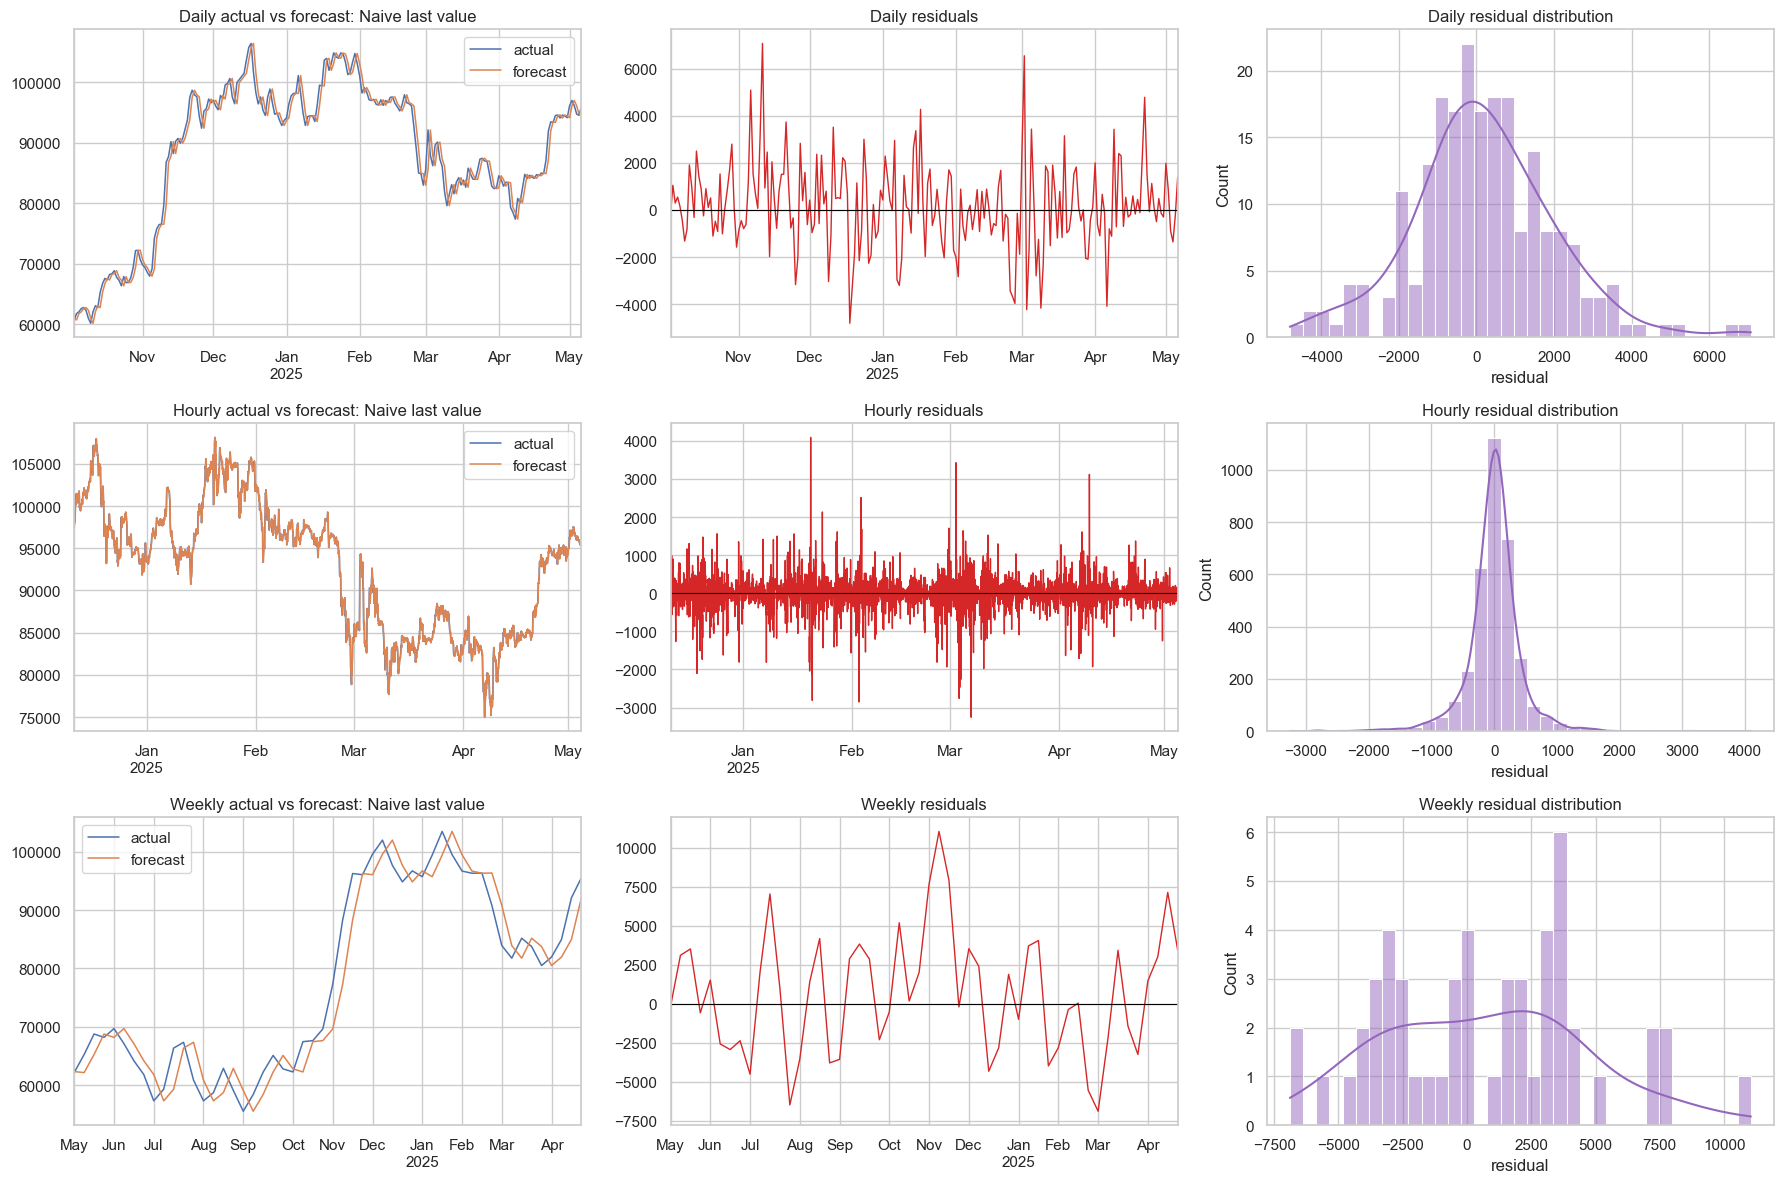

,frequency,model,interval_start,interval_end,window,mean_abs_error
0,daily,Naive last value,2025-02-24 00:00:00,2025-03-09 00:00:00,14,2879.53
1,daily,Naive last value,2025-02-25 00:00:00,2025-03-10 00:00:00,14,2799.29
2,daily,Naive last value,2025-02-26 00:00:00,2025-03-11 00:00:00,14,2670.12
3,daily,Naive last value,2025-02-23 00:00:00,2025-03-08 00:00:00,14,2606.37
4,daily,Naive last value,2025-03-01 00:00:00,2025-03-14 00:00:00,14,2603.25
5,hourly,Naive last value,2025-02-28 01:00:00,2025-03-07 00:00:00,168,511.46
6,hourly,Naive last value,2025-02-28 02:00:00,2025-03-07 01:00:00,168,504.22
7,hourly,Naive last value,2025-02-28 22:00:00,2025-03-07 21:00:00,168,500.68
8,hourly,Naive last value,2025-03-01 02:00:00,2025-03-08 01:00:00,168,500.42
9,hourly,Naive last value,2025-02-28 23:00:00,2025-03-07 22:00:00,168,500.40


In [14]:
def residual_frame(frequency, model_name):
    y_test = prepared[frequency]['y_test']
    pred = prediction_store[frequency][model_name]['test_pred'].reindex(y_test.index)
    frame = pd.DataFrame({'actual': y_test, 'forecast': pred}).dropna()
    frame['residual'] = frame['actual'] - frame['forecast']
    frame['abs_error'] = frame['residual'].abs()
    frame['pct_return'] = frame['actual'].pct_change()
    return frame

fig, axes = plt.subplots(len(best_by_frequency), 3, figsize=(18, 4 * len(best_by_frequency)))
if len(best_by_frequency) == 1:
    axes = np.array([axes])

worst_interval_rows = []
for row_idx, (_, row) in enumerate(best_by_frequency.iterrows()):
    frequency = row['frequency']
    model_name = row['model']
    frame = residual_frame(frequency, model_name)

    frame[['actual', 'forecast']].plot(ax=axes[row_idx, 0], linewidth=1.1)
    axes[row_idx, 0].set_title(f'{frequency.title()} actual vs forecast: {model_name}')
    axes[row_idx, 0].set_xlabel('')

    frame['residual'].plot(ax=axes[row_idx, 1], color='tab:red', linewidth=1.0)
    axes[row_idx, 1].axhline(0, color='black', linewidth=0.8)
    axes[row_idx, 1].set_title(f'{frequency.title()} residuals')
    axes[row_idx, 1].set_xlabel('')

    sns.histplot(frame['residual'], bins=35, kde=True, ax=axes[row_idx, 2], color='tab:purple')
    axes[row_idx, 2].set_title(f'{frequency.title()} residual distribution')

    window = DATA_CONFIG[frequency]['error_window']
    rolling_error = frame['abs_error'].rolling(window=window, min_periods=1).mean()
    for end_time in rolling_error.sort_values(ascending=False).head(5).index:
        pos = frame.index.get_loc(end_time)
        start_time = frame.index[max(0, pos - window + 1)]
        worst_interval_rows.append({
            'frequency': frequency,
            'model': model_name,
            'interval_start': start_time,
            'interval_end': end_time,
            'window': window,
            'mean_abs_error': rolling_error.loc[end_time],
        })

plt.tight_layout()
plt.show()

display(pd.DataFrame(worst_interval_rows).round({'mean_abs_error': 2}))


In [15]:
shock_rows = []
shock_detail_rows = []
for _, row in best_by_frequency.iterrows():
    frequency = row['frequency']
    model_name = row['model']
    frame = residual_frame(frequency, model_name).dropna(subset=['pct_return'])
    threshold = frame['pct_return'].abs().quantile(0.90)
    frame['shock_type'] = np.where(
        frame['pct_return'] >= threshold,
        'sharp growth',
        np.where(frame['pct_return'] <= -threshold, 'sharp drop', 'normal'),
    )

    for shock_type, group in frame.groupby('shock_type'):
        metrics = regression_metrics(group['actual'], group['forecast'], prepared[frequency]['y_train'])
        shock_rows.append({
            'frequency': frequency,
            'model': model_name,
            'period_type': shock_type,
            'n_observations': len(group),
            'MAE': metrics['MAE'],
            'SMAPE': metrics['SMAPE'],
            'MASE': metrics['MASE'],
        })

    shocks = frame[frame['shock_type'] != 'normal'].copy()
    shocks['abs_pct_return'] = shocks['pct_return'].abs()
    for time, values in shocks.sort_values('abs_pct_return', ascending=False).head(10).iterrows():
        shock_detail_rows.append({
            'frequency': frequency,
            'model': model_name,
            'time': time,
            'shock_type': values['shock_type'],
            'pct_return': values['pct_return'],
            'actual': values['actual'],
            'forecast': values['forecast'],
            'abs_error': values['abs_error'],
        })

shock_summary = pd.DataFrame(shock_rows)
shock_details = pd.DataFrame(shock_detail_rows)

display(shock_summary.round({'MAE': 2, 'SMAPE': 3, 'MASE': 3}))
display(shock_details.round({'pct_return': 4, 'actual': 2, 'forecast': 2, 'abs_error': 2}))


,frequency,model,period_type,n_observations,MAE,SMAPE,MASE
0,daily,Naive last value,normal,193,1081.13,1.224,2.153
1,daily,Naive last value,sharp drop,8,3965.02,4.363,7.894
2,daily,Naive last value,sharp growth,14,4063.63,4.811,8.091
3,hourly,Naive last value,normal,3123,193.57,0.209,1.400
4,hourly,Naive last value,sharp drop,185,1058.92,1.162,7.659
5,hourly,Naive last value,sharp growth,162,1024.31,1.125,7.409
6,weekly,Naive last value,normal,45,2714.25,3.638,1.974
7,weekly,Naive last value,sharp drop,1,6487.85,10.121,4.719
8,weekly,Naive last value,sharp growth,5,8161.94,10.324,5.937


,frequency,model,time,shock_type,pct_return,actual,forecast,abs_error
0,daily,Naive last value,2024-11-11 00:00:00,sharp growth,0.0887,86822.68,79747.06,7075.62
1,daily,Naive last value,2025-03-02 00:00:00,sharp growth,0.0765,92145.09,85595.09,6550.00
2,daily,Naive last value,2024-11-06 00:00:00,sharp growth,0.0736,74265.09,69175.20,5089.89
3,daily,Naive last value,2025-04-22 00:00:00,sharp growth,0.0549,91946.42,87160.44,4785.99
4,daily,Naive last value,2025-04-06 00:00:00,sharp drop,-0.0491,79307.86,83398.59,4090.73
5,daily,Naive last value,2025-03-09 00:00:00,sharp drop,-0.0484,81931.42,86100.98,4169.56
6,daily,Naive last value,2025-03-03 00:00:00,sharp drop,-0.0460,87910.60,92145.09,4234.49
7,daily,Naive last value,2024-12-18 00:00:00,sharp drop,-0.0452,101648.81,106460.35,4811.54
8,daily,Naive last value,2025-02-26 00:00:00,sharp drop,-0.0446,85028.05,88997.91,3969.87
9,daily,Naive last value,2025-04-09 00:00:00,sharp growth,0.0443,80819.64,77391.46,3428.19


## Discussion

The executed one-step-ahead experiment shows that `Naive last value` is the strongest overall method for daily, hourly, and weekly BTC forecasts. This is a meaningful result, not a failure of the pipeline: short-horizon BTC prices are highly autocorrelated and often close to a random-walk process, so the previous observed value is a hard benchmark to beat.

Linear models lag because Ridge, Lasso, and ElasticNet estimate a smoothed conditional mean from lagged BTC, OHLC, technical indicators, and cross-market features. Regularization controls variance, but it also dampens reactions to abrupt regime changes. In the results table this appears as larger shock-period errors and, for several models, a positive train/test gap.

Tree-based and boosting models capture nonlinear interactions between technical indicators, ETH, crypto equities, broad market indices, VIX, commodities, FX, and macro variables. Their weakness here is extrapolation: when the test segment reaches BTC levels or shock dynamics not represented in train, trees and boosting tend to underreact. Stacking inherits that limitation and can amplify it when the weekly validation block is small.

The MLP neural regressor is a compact neural baseline. It can model nonlinearities but is sensitive to non-stationarity and scaling. In this run it does not beat persistence. The original project also contains LSTM, GRU, stacked LSTM, and CNN-LSTM experiments; those sequence models are more expressive, but they need strict train-only scaling, walk-forward validation, and early stopping to avoid overfitting.

Feature importance is interpreted for the best non-baseline ML model per frequency. Important predictors should be read as predictive signals, not causal drivers. The dominant signals are expected to come from BTC OHLC/lag/rolling and trend features, with secondary contributions from ETH, MicroStrategy/mining equities, NASDAQ/S&P/VIX, sentiment, and slower macro indicators at daily or weekly horizons.


## Conclusion

The report satisfies the Modern Methods of Data Analysis requirements: the datasets are larger than 50 observations and 7-10 features; the notebook documents data collection, dataset statistics, preprocessing, missing/outlier handling, train-only scaling, feature selection, multiple ML/DM methods, comparison, interpretation, and error analysis.

In the executed experiment, the best method on all three frequencies is `Naive last value`. This establishes a strong persistence baseline for BTC one-step forecasting. The best non-baseline ML models are still useful analytically: they show which heterogeneous indicators contain predictive signal, where nonlinear models underreact, and how errors concentrate during sharp growth and drop periods.

Main limitations: BTC non-stationarity, regime shifts, weak extrapolation outside the train price range, possible feature timestamp mismatches for macro releases, and the difficulty of predicting crypto shocks from historical tabular indicators alone.

Further improvements: walk-forward retraining, nested time-series validation, probabilistic intervals, quantile loss, release-time-aware macro features, richer on-chain data, transaction-cost-aware evaluation, and sequence neural models evaluated with the corrected leakage-safe pipeline.
